In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import numbers

from src.data_cleaning import ISMN as utils
from src.data_cleaning.general import plot, validate_time_index, validate_data_cleaning_input, filter_df
from src import constants as c

# Data Understanding and Preparation of the ISMN Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for the <10 cm depth soil temperature variable for all ISMN sensors in `data/raw/ISMN`. The cleaned data will then be exported to `data/cleaned/ISMN`.

---

### Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **Map of ISMN Stations**
3. **ISMN Stations**
    - *3.1 Aberdeen-35-WNW*
    - *3.2 Jamestown-38-WSW*
    - *3.3 Gobblers Knob*
    - *3.4 Nenana*
    - *3.5 L23*
    - *3.6 L38*
    - *3.7 NST-07*
    - *3.8 NST-09*
    - *3.9 SOD012*
    - *3.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
# key variables
max_depth = 0.10 # in m, exclusive
short_variable = 'ts' # soil temperature
long_variable = 'soil_temp'
y_label = 'Soil Temperature (C)'
threshold = 10 # in C; for detecting outliers.
system = 'ISMN'

# path variables
raw_data_path = Path('../data/raw/ISMN')
cleaned_data_path = Path('../data/cleaned')
Path(cleaned_data_path).mkdir(parents=True, exist_ok=True)

### 1.2 Functions

In [3]:
def soil_temp_data_cleaning(data_path: Path, depth: numbers.Real,
                            short_feature: str, long_feature: str,
                            temp_threshold: numbers.Real,
                            date_range=None) -> pd.DataFrame:
    """
    Preprocessing of raw ISMN soil temperature data.
    :param data_path: full path to raw ISMN data
    :param depth: in m; exclusive
    :param short_feature: abbreviated variable name
    :param long_feature: full variable name
    :param temp_threshold: in C; for detecting outliers
    :param date_range: list of datetime objects. Data outside this range is filtered out. Min is inclusive and max is exclusive. Assumed that input is in the same timezone as df.index. If date_range is not valid for given df, date_range will be adjusted to be valid.
    :return: cleaned dataframe
    """
    # validate inputs
    validate_data_cleaning_input(data_path, date_range)

    # preprocess data
    df = utils.collect_data(data_path, depth, short_feature, long_feature)
    df = utils.create_timestamp_col(df)
    df = filter_df(df, date_range)
    df = utils.convert_nan(df, long_feature)

    # convert outlier spikes/drops to NaN
    df_outliers = utils.find_outlier_spikes(df, long_feature, temp_threshold)
    df = utils.make_nan_indices(df, long_feature, df_outliers)

    # only keep required column
    if c.ISMN_KEY_COLS is not None:
        df = df[c.ISMN_KEY_COLS]

    return df

def soil_temp_data_reporting(df: pd.DataFrame, long_feature: str, station_name: str, ylabel: str) -> None:
    """
    Reporting of preprocessed ISMN soil temperature data.
    :param df: can be output from soil_temp_data_cleaning()
    :param long_feature: full variable name
    :param station_name: official name of ISMN station
    :param ylabel: y-label for plot
    :return:
    """
    # check input values
    if long_feature not in df.columns:
        raise KeyError(f'df missing required column "{long_feature}".')
    # check input df index
    validate_time_index(df)

    print('Summary statistics:')
    display(df.describe())
    print('Show head of df:')
    display(df.head())

    # report NaN count and proportion
    na_count = df.isnull().sum()[long_variable]
    print(f'There are {na_count} nulls out of {len(df)} datapoints ({round(na_count/len(df),2)}% missing).')

    # report NaN gaps
    nan_df = utils.get_nan_gaps(df, long_feature)
    if not nan_df.empty:
        nan_df = utils.add_missed_transitions_col(nan_df)
        nan_df = nan_df.loc[(nan_df['gap_length_hours'] >= 72) | (nan_df['possible_transition'] == True)]
        if not nan_df.empty:
            print('Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:')
            display(nan_df)
        else:
            print('No significant NaN gaps to report.')
    else:
        print('No NaN gaps to report.')

    plot(df, long_feature, station=station_name, system=system, form='line', y_label=ylabel)

## 2. Map of ISMN Stations

In [4]:
utils.map_stations(c.SITE_SURVEY_PATH, save_image=False)

## 3. ISMN Stations

### 3.1 Aberdeen-35-WNW

Summary statistics:


,soil_temp
count,130673.000000
mean,7.555543
std,8.429433
min,-10.600000
25%,-0.300000
50%,6.600000
75%,16.000000
max,25.500000


Show head of df:


,soil_temp
UTC_timestamp,
2009-10-28 02:00:00+00:00,6.1
2009-10-28 03:00:00+00:00,6.1
2009-10-28 04:00:00+00:00,6.0
2009-10-28 05:00:00+00:00,6.0
2009-10-28 06:00:00+00:00,5.9


There are 2381 nulls out of 133054 datapoints (0.02% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
6,2010-04-07 08:00:00+00:00,2010-04-20 16:00:00+00:00,321,5.0,8.0,False
55,2018-12-25 16:00:00+00:00,2019-01-01 00:00:00+00:00,153,-1.6,-2.2,False
61,2021-11-03 17:00:00+00:00,2022-01-01 00:00:00+00:00,1400,3.3,-1.0,True
69,2024-02-08 06:00:00+00:00,2024-02-11 16:00:00+00:00,83,-0.1,-0.2,False
80,2024-12-23 15:00:00+00:00,2024-12-26 17:00:00+00:00,75,-0.6,-0.3,False


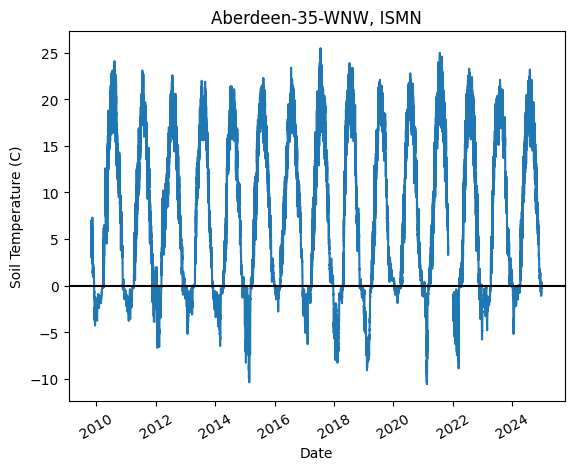

In [5]:
aberdeen_df = soil_temp_data_cleaning(data_path=raw_data_path / c.ABERDEEN_NAME,
                                      depth=max_depth,
                                      short_feature=short_variable,
                                      long_feature=long_variable,
                                      temp_threshold=threshold,
                                      date_range=c.DATE_RANGE)

soil_temp_data_reporting(aberdeen_df, long_feature=long_variable, station_name=c.ABERDEEN_NAME, ylabel=y_label)

There are five NaN gaps longer than 72 hours in duration. Of these five, one gap contained at least one F/T transition, which is from 2021/11/03 to 2022/01/01 (1400 hour duration).

Inspection of the plot shows that the dataset contains at least 31 F/T transitions, discounting transitions that occurred during long gaps of missing data. No odd behaviour is visible.


In [6]:
# export to csv
aberdeen_df.to_csv(cleaned_data_path / f'{c.ABERDEEN_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.2 Jamestown-38-WSW

Summary statistics:


,soil_temp
count,121102.000000
mean,7.617010
std,8.754423
min,-11.500000
25%,-0.400000
50%,6.600000
75%,16.400000
max,24.500000


Show head of df:


,soil_temp
UTC_timestamp,
2010-08-19 20:00:00+00:00,19.4
2010-08-19 21:00:00+00:00,19.5
2010-08-19 22:00:00+00:00,19.7
2010-08-19 23:00:00+00:00,19.8
2010-08-20 00:00:00+00:00,19.9


There are 4854 nulls out of 125956 datapoints (0.04% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
9,2015-01-05 15:00:00+00:00,2015-01-15 19:00:00+00:00,245,-3.6,-4.1,False
10,2015-04-18 16:00:00+00:00,2015-05-15 19:00:00+00:00,652,5.5,8.9,False
39,2018-12-25 16:00:00+00:00,2019-01-01 00:00:00+00:00,153,-0.2,-2.4,False
58,2021-11-03 17:00:00+00:00,2022-01-01 00:00:00+00:00,1400,5.0,-1.0,True
62,2022-03-21 02:00:00+00:00,2022-03-30 14:00:00+00:00,229,-0.5,-0.4,False
67,2022-04-16 21:00:00+00:00,2022-06-04 20:00:00+00:00,1176,-0.2,11.8,True
84,2023-11-29 16:00:00+00:00,2023-11-29 17:00:00+00:00,2,-0.2,0.5,True
203,2024-12-01 09:00:00+00:00,2024-12-02 03:00:00+00:00,19,0.2,-1.1,True
204,2024-12-02 05:00:00+00:00,2024-12-02 20:00:00+00:00,16,-1.1,0.1,True
205,2024-12-02 22:00:00+00:00,2024-12-03 01:00:00+00:00,4,0.1,-1.1,True


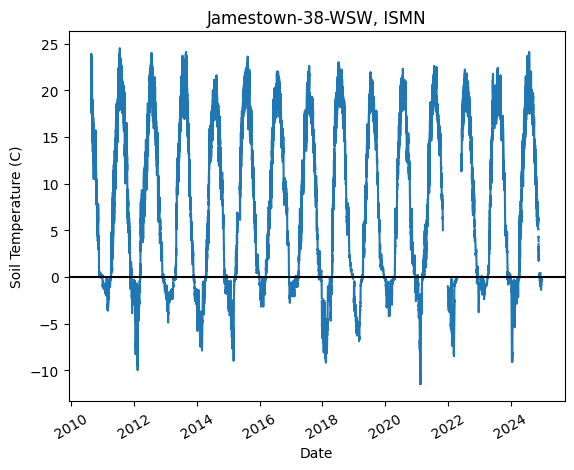

In [7]:
jamestown_df = soil_temp_data_cleaning(data_path=raw_data_path / c.JAMESTOWN_NAME,
                                       depth=max_depth,
                                       short_feature=short_variable,
                                       long_feature=long_variable,
                                       temp_threshold=threshold,
                                       date_range=c.DATE_RANGE)

soil_temp_data_reporting(jamestown_df, long_feature=long_variable, station_name=c.JAMESTOWN_NAME, ylabel=y_label)

There are six NaN gaps longer than 72 hours in duration. Of these long duration gaps, an F/T transition occurred in two of them:
1. 2021/11/03 to 2022/01/01 (1400 hours)
2. 2022/04/16 to 2022/06/04 (1176 hours)

Additionally, there are four short duration gaps where the temperature crossed the freezing point.
1. 2023/11/29 to 2023/11/29
2. 2024/12/01 to 2024/12/02
3. 2024/12/02 to 2024/12/02
4. 2024/12/02 to 2024/12/03

Inspection of the plot shows that the dataset contains at least 27 F/T transitions, discounting transitions that occurred during long gaps of missing data. No odd behaviour is visible.

Check what's happening around short duration gaps where the temperature crossed the freezing point.

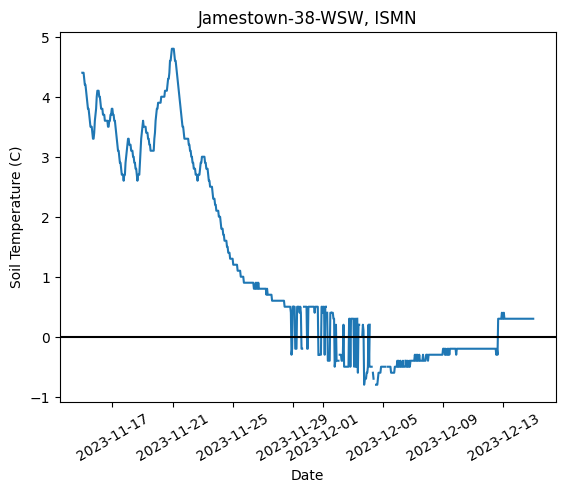

In [8]:
plot(jamestown_df, long_variable, station=c.JAMESTOWN_NAME, system=system, form='line',
           y_label=y_label, start=datetime(2023, 11, 15), end=datetime(2023, 12, 15))

Odd behaviour from 2023/11/28 to 2023/12/04. Missing data is also more frequent than normal in this time range. The quality of the data is suspect, so convert the data from 2023/11/28 22:00 to 2023/12/04 13:00 in this range to NaN. Unfortunately, this means one F/T transition will be lost.

In [9]:
jamestown_df = utils.make_nan_window(jamestown_df, long_variable, start=datetime(2023, 11, 28, 22), end=datetime(2023, 12, 4, 13))

Now plot the data in 2024/12 to inspect the freezing point crossings.

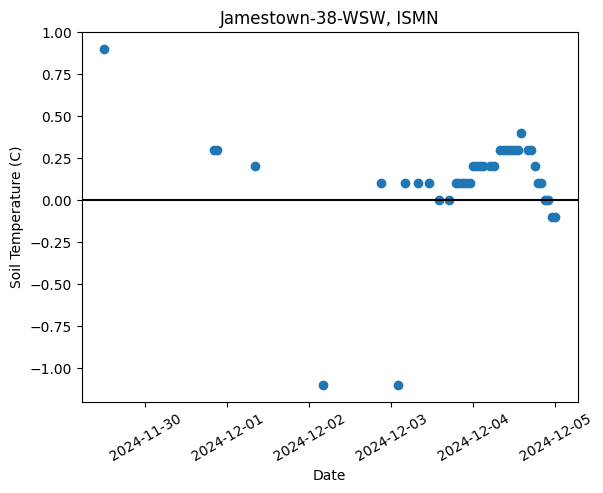

In [10]:
plot(jamestown_df, long_variable, station=c.JAMESTOWN_NAME, system=system, form='scatter',
     y_label=y_label, start=datetime(2024, 11, 29), end=datetime(2024, 12, 5))

The freezing point crossings on 2024/12/02 and 2024/12/03 are rather suspect. Convert the data from 2024/12/02 04:00 to 2024/12/03 02:00 to NaN.

In [11]:
jamestown_df = utils.make_nan_window(jamestown_df, long_variable, start=datetime(2024, 12, 2, 4), end=datetime(2024, 12, 3, 2))

In [12]:
# export to csv
jamestown_df.to_csv(cleaned_data_path / f'{c.JAMESTOWN_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.3 Gobblers Knob

Summary statistics:


,soil_temp
count,153771.000000
mean,0.180036
std,7.244836
min,-31.200000
25%,-4.900000
50%,-1.100000
75%,6.666670
max,21.111100


Show head of df:


,soil_temp
UTC_timestamp,
2007-01-01 00:00:00+00:00,-7.4
2007-01-01 01:00:00+00:00,-7.4
2007-01-01 02:00:00+00:00,-7.4
2007-01-01 03:00:00+00:00,-7.6
2007-01-01 04:00:00+00:00,-7.7


There are 2103 nulls out of 155874 datapoints (0.01% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
209,2012-02-23 09:00:00+00:00,2012-03-12 23:00:00+00:00,447,-6.6,-10.70000,False
270,2022-06-01 16:00:00+00:00,2022-07-05 15:00:00+00:00,815,5.0,2.77778,False


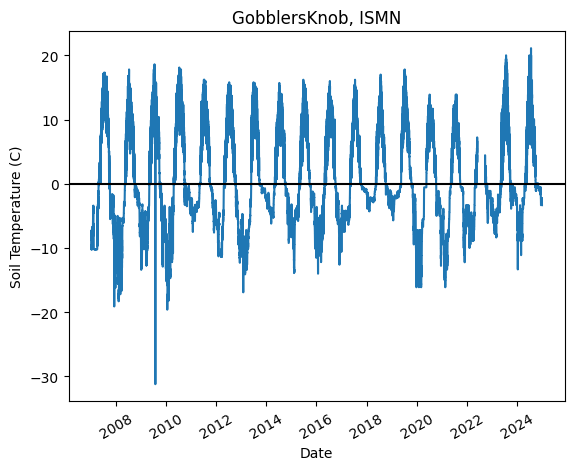

In [13]:
gobblers_knob_df = soil_temp_data_cleaning(data_path=raw_data_path / c.GOBBLERS_KNOB_NAME,
                                           depth=max_depth,
                                           short_feature=short_variable,
                                           long_feature=long_variable,
                                           temp_threshold=threshold,
                                           date_range=c.DATE_RANGE)

soil_temp_data_reporting(gobblers_knob_df, long_feature=long_variable, station_name=c.GOBBLERS_KNOB_NAME, ylabel=y_label)

There are two NaN gaps longer than 72 hours in duration. No F/T transitions occurs during any of the following long gaps:
1. 2022/06/01 to 2022/07/05 (809 hours)
2. 2012/02/23 to 2012/03/12 (447 hours)

Inspection of the plot shows that the dataset contains at least 36 F/T transitions.

However, there's some odd behaviour during the summer of 2010 that was not detected by find_outlier_spikes(). Inspect the data.

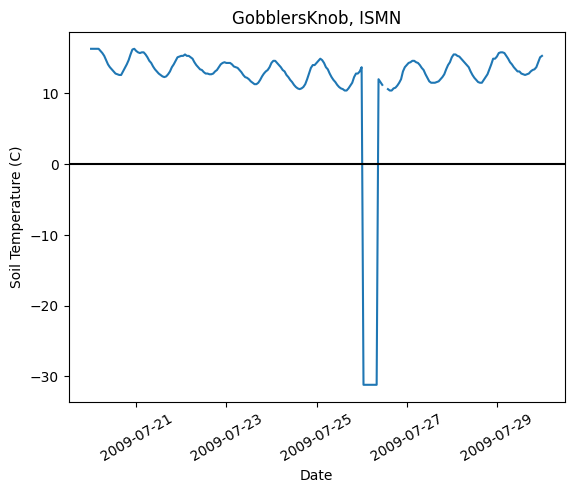

In [14]:
plot(gobblers_knob_df, long_variable, station=c.GOBBLERS_KNOB_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2009, 7, 20), end=datetime(2009, 7, 30))

It's unrealistic for the soil temperature to suddenly drop 40 C in the middle of summer. Cross-checking with other temperature sensors at the
station suggests that this drop is from a series of bad measurements. Convert data from 2009/07/26 01:00 to 2009/07/26 08:00 to NaN.
![](../images/gobblers_knob_anomaly.png)

In [15]:
gobblers_knob_df = utils.make_nan_window(gobblers_knob_df, long_variable, start=datetime(2009, 7, 26, 1), end=datetime(2009, 7, 26, 8))

In [16]:
# export to csv
gobblers_knob_df.to_csv(cleaned_data_path / f'{c.GOBBLERS_KNOB_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.4 Nenana

Summary statistics:


,soil_temp
count,97104.00000
mean,2.90522
std,6.50977
min,-10.20000
25%,-1.66667
50%,-0.40000
75%,8.50000
max,24.50000


Show head of df:


,soil_temp
UTC_timestamp,
2012-09-21 20:00:00+00:00,8.3
2012-09-21 21:00:00+00:00,9.1
2012-09-21 22:00:00+00:00,10.1
2012-09-21 23:00:00+00:00,10.4
2012-09-22 00:00:00+00:00,10.5


There are 10430 nulls out of 107534 datapoints (0.1% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
41,2013-12-25 05:00:00+00:00,2013-12-28 04:00:00+00:00,72,-3.2000,-4.3000,False
106,2015-11-15 03:00:00+00:00,2015-11-20 06:00:00+00:00,124,-1.4000,-2.1000,False
116,2015-12-10 12:00:00+00:00,2015-12-13 15:00:00+00:00,76,-2.5000,-2.6000,False
125,2015-12-24 16:00:00+00:00,2015-12-28 22:00:00+00:00,103,-2.2000,-2.8000,False
145,2016-01-20 21:00:00+00:00,2016-01-25 03:00:00+00:00,103,-4.8000,-5.8000,False
247,2016-11-17 22:00:00+00:00,2016-12-31 21:00:00+00:00,1056,-2.8000,-2.0000,False
255,2017-01-06 12:00:00+00:00,2017-01-11 10:00:00+00:00,119,-1.8000,-3.0000,False
257,2017-01-11 22:00:00+00:00,2017-01-20 10:00:00+00:00,205,-3.1000,-3.6000,False
259,2017-01-21 20:00:00+00:00,2017-01-27 01:00:00+00:00,126,-3.6000,-3.6000,False
264,2017-02-02 15:00:00+00:00,2017-02-05 17:00:00+00:00,75,-2.6000,-3.2000,False


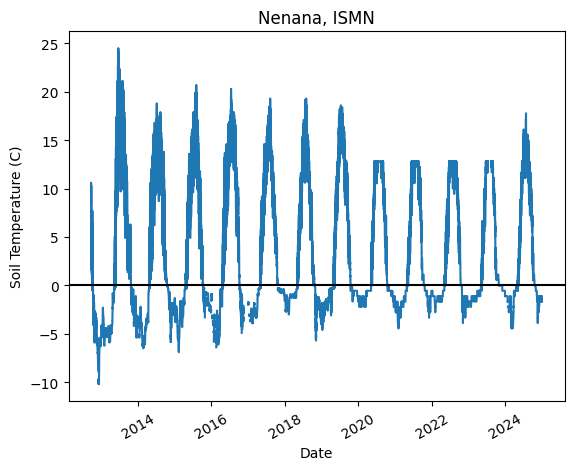

In [17]:
nenana_df = soil_temp_data_cleaning(data_path=raw_data_path / c.NENANA_NAME,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    temp_threshold=threshold,
                                    date_range=c.DATE_RANGE)

soil_temp_data_reporting(nenana_df, long_feature=long_variable, station_name=c.NENANA_NAME, ylabel=y_label)

Nenana has a relatively high proportion of NaNs compared to the three stations above. There are 19 NaN gaps that are at least 72 hours in duration, but none of these seemingly contain an F/T transition.

There is one short-term gap where the temperature crossed the freezing point: 2017/10/21 05:00 to 2017/10/23 02:00.

Inspection of the plot shows that the dataset contains at least 25 F/T transitions. There seems to be some off behaviour during the summers from 2020-2024, but this shouldn't be a concern for this experiment.

Now, let's look at the NaN gap that crossed the freezing point.

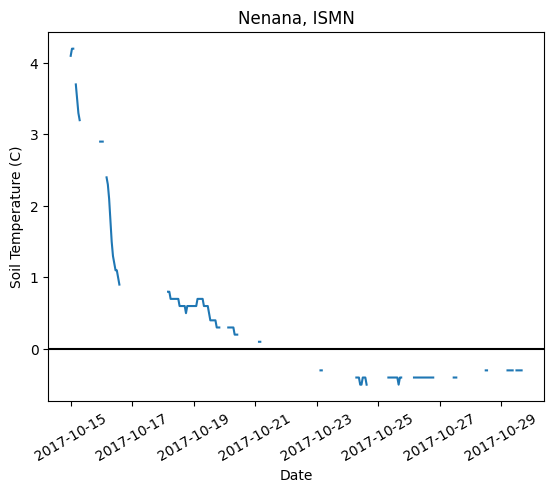

In [18]:
plot(nenana_df, long_variable, station=c.NENANA_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2017, 10, 15), end=datetime(2017, 10, 30))

The data around this F/T is sparse, which may cause problems for predictions.

In [19]:
# export to csv
nenana_df.to_csv(cleaned_data_path / f'{c.NENANA_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.5 L23

Summary statistics:


,soil_temp
count,53798.000000
mean,2.811722
std,7.690446
min,-15.800000
25%,-3.000000
50%,2.100000
75%,9.000000
max,36.900000


Show head of df:


,soil_temp
UTC_timestamp,
2010-08-01 00:00:00+00:00,8.5
2010-08-01 01:00:00+00:00,8.3
2010-08-01 02:00:00+00:00,9.2
2010-08-01 03:00:00+00:00,11.4
2010-08-01 04:00:00+00:00,14.0


There are 2 nulls out of 53800 datapoints (0.0% missing).
No significant NaN gaps to report.


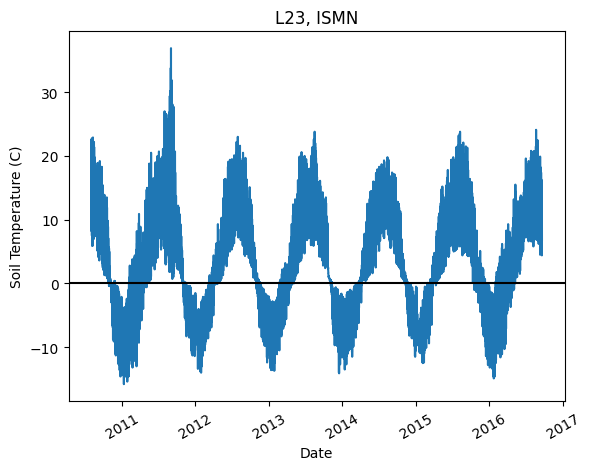

In [20]:
L23_df = soil_temp_data_cleaning(data_path=raw_data_path / c.L23_NAME,
                                 depth=max_depth,
                                 short_feature=short_variable,
                                 long_feature=long_variable,
                                 temp_threshold=threshold,
                                 date_range=c.DATE_RANGE)

soil_temp_data_reporting(L23_df, long_feature=long_variable, station_name=c.L23_NAME, ylabel=y_label)

12 F/T transitions can be seen.

The dataset has much higher variance compared to the others. Zoom in on an F/T transition to get a better idea of how the data looks like.

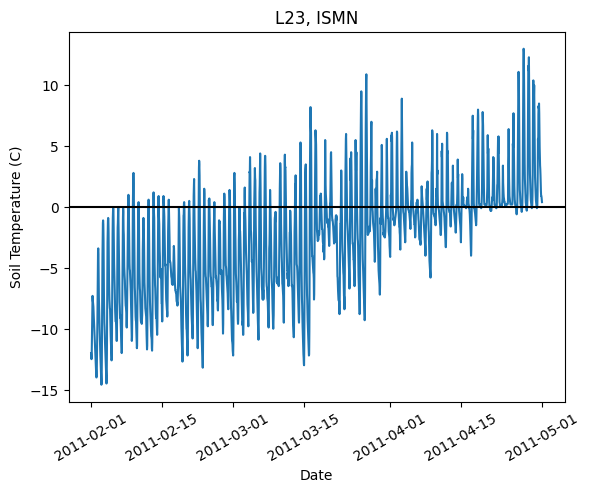

In [21]:
plot(L23_df, long_variable, station=c.L23_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2011, 2, 1), end=datetime(2011, 5, 1))

This dataset will likely be problematic in making predictions.

In [22]:
# export to csv
L23_df.to_csv(cleaned_data_path / f'{c.L23_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.6 L38

Summary statistics:


,soil_temp
count,53800.000000
mean,4.290838
std,7.792174
min,-16.500000
25%,-1.500000
50%,4.100000
75%,10.500000
max,26.500000


Show head of df:


,soil_temp
UTC_timestamp,
2010-08-01 00:00:00+00:00,12.3
2010-08-01 01:00:00+00:00,12.1
2010-08-01 02:00:00+00:00,12.7
2010-08-01 03:00:00+00:00,13.9
2010-08-01 04:00:00+00:00,16.2


There are 0 nulls out of 53800 datapoints (0.0% missing).
No NaN gaps to report.


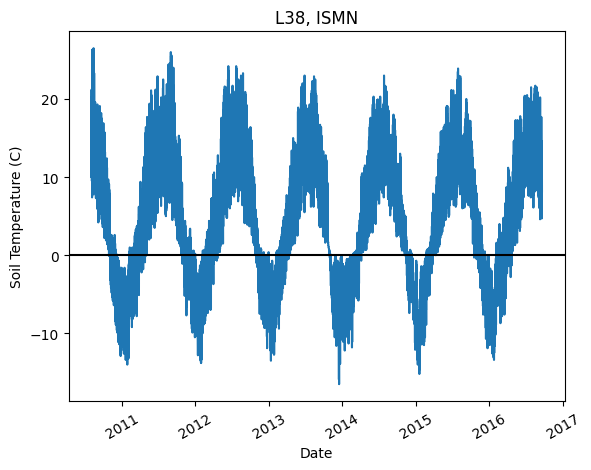

In [23]:
L38_df = soil_temp_data_cleaning(data_path=raw_data_path / c.L38_NAME,
                                 depth=max_depth,
                                 short_feature=short_variable,
                                 long_feature=long_variable,
                                 temp_threshold=threshold,
                                 date_range=c.DATE_RANGE)

soil_temp_data_reporting(L38_df, long_feature=long_variable, station_name=c.L38_NAME, ylabel=y_label)

12 F/T transitions can be seen like in L23.

In [24]:
# export to csv
L38_df.to_csv(cleaned_data_path / f'{c.L38_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.7 NST-07

Summary statistics:


,soil_temp
count,73427.000000
mean,5.790998
std,7.292820
min,-36.200000
25%,-0.500000
50%,5.600000
75%,11.900000
max,27.400000


Show head of df:


,soil_temp
UTC_timestamp,
2008-06-28 05:00:00+00:00,19.6
2008-06-28 06:00:00+00:00,20.9
2008-06-28 07:00:00+00:00,22.3
2008-06-28 08:00:00+00:00,22.6
2008-06-28 09:00:00+00:00,21.8


There are 16143 nulls out of 89570 datapoints (0.18% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
1,2009-09-26 13:00:00+00:00,2010-05-16 07:00:00+00:00,5563,9.3,14.9,False
2,2013-06-18 13:00:00+00:00,2013-06-30 09:00:00+00:00,285,19.5,19.0,False
3,2016-06-24 09:00:00+00:00,2017-08-25 05:00:00+00:00,10245,11.3,16.1,False
5,2018-07-13 10:00:00+00:00,2018-07-14 05:00:00+00:00,20,20.9,-36.2,True


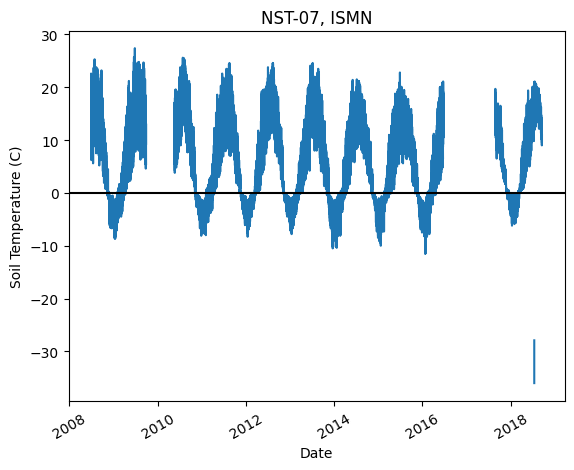

In [25]:
NST_07_df = soil_temp_data_cleaning(data_path=raw_data_path / c.NST_07_NAME,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    temp_threshold=threshold,
                                    date_range=c.DATE_RANGE)

soil_temp_data_reporting(NST_07_df, long_feature=long_variable, station_name=c.NST_07_NAME, ylabel=y_label)

There's a relatively large proportion of data missing. There are three NaN gaps greater than 72 hours in duration:
- 2016/06/24 to 2017/08/25 (10,245 hours)
- 2009/09/26 to 2010/05/16 (5563 hours)
- 2013/06/18 to 2013/06/30 (285 hours)

The first two gaps should've contained F/T transitions.

The dataset contains 16 F/T transitions. At least four F/T transitions were missed due to large NaN gaps.

There's some odd behaviour in 2018, so zoom in to see what's happening.

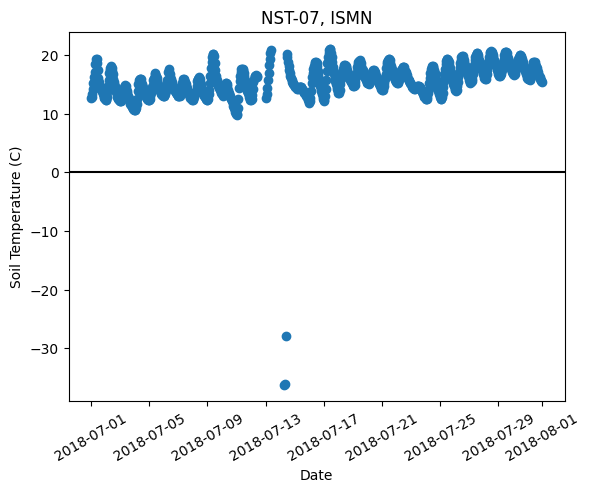

In [26]:
plot(NST_07_df, long_variable, station=c.NST_07_NAME, system=system, form='scatter',
     y_label=y_label, start=datetime(2018, 7, 1), end=datetime(2018, 8, 1))

A 50 degree drop in the middle of the summer is likely due to erroneous measurements. The data from 2018/07/14 06:00 to 2018/07/14 10:00 will be converted to NaN.

In [27]:
NST_07_df = utils.make_nan_window(NST_07_df, long_variable, start=datetime(2018, 7, 14, 6), end=datetime(2018, 7, 14, 10))

In [28]:
# export to csv
NST_07_df.to_csv(cleaned_data_path / f'{c.NST_07_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.8 NST-09

Summary statistics:


,soil_temp
count,77408.000000
mean,6.208807
std,8.729682
min,-17.200000
25%,-0.600000
50%,5.900000
75%,13.300000
max,32.200000


Show head of df:


,soil_temp
UTC_timestamp,
2008-06-29 03:00:00+00:00,20.0
2008-06-29 04:00:00+00:00,21.0
2008-06-29 05:00:00+00:00,21.7
2008-06-29 06:00:00+00:00,23.5
2008-06-29 07:00:00+00:00,24.1


There are 18278 nulls out of 95686 datapoints (0.19% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2009-09-26 11:00:00+00:00,2010-05-16 05:00:00+00:00,5563,12.8,17.3,False
1,2013-06-18 11:00:00+00:00,2013-06-30 06:00:00+00:00,284,28.1,20.2,False
2,2014-07-19 08:00:00+00:00,2014-10-18 09:00:00+00:00,2186,21.2,8.9,False
3,2016-06-24 06:00:00+00:00,2017-08-25 02:00:00+00:00,10245,13.2,10.0,False


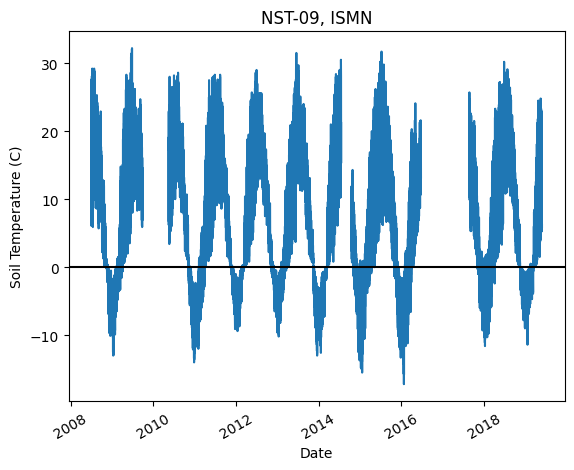

In [29]:
NST_09_df = soil_temp_data_cleaning(data_path=raw_data_path / c.NST_09_NAME,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    temp_threshold=threshold,
                                    date_range=c.DATE_RANGE)

soil_temp_data_reporting(NST_09_df, long_feature=long_variable, station_name=c.NST_09_NAME, ylabel=y_label)

There's a relatively large proportion of data missing. There are four NaN gaps greater than 72 hours in duration:
- 2016/06/24 to 2017/08/25 (10,245 hours)
- 2009/09/26 to 2010/05/16 (5563 hours)
- 2014/07/19 to 2014/10/18 (2186 hours)
- 2013/06/18 to 2013/06/30 (285 hours)

This station has the same NaN gaps as NST-07, except for the 2186-hour duration gap.

The dataset contains 16 F/T transitions. At least four F/T transitions were missed due to large NaN gaps.

In [30]:
# export to csv
NST_09_df.to_csv(cleaned_data_path / f'{c.NST_09_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.9 SOD012

Summary statistics:


,soil_temp
count,107717.000000
mean,4.366152
std,6.786173
min,-9.500000
25%,-0.700000
50%,0.600000
75%,10.300000
max,25.900000


Show head of df:


,soil_temp
UTC_timestamp,
2011-09-18 00:00:00+00:00,4.9
2011-09-18 01:00:00+00:00,4.9
2011-09-18 02:00:00+00:00,4.9
2011-09-18 03:00:00+00:00,4.7
2011-09-18 04:00:00+00:00,4.3


There are 8779 nulls out of 116496 datapoints (0.08% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2011-09-25 00:00:00+00:00,2011-10-15 23:00:00+00:00,504,5.3,0.6,False
2,2011-10-30 00:00:00+00:00,2011-11-19 23:00:00+00:00,504,0.9,-3.3,True
3,2011-11-27 00:00:00+00:00,2011-12-17 23:00:00+00:00,504,-0.5,-0.1,False
4,2012-01-01 00:00:00+00:00,2012-01-14 23:00:00+00:00,336,-0.4,-0.6,False
5,2012-01-29 00:00:00+00:00,2012-02-18 23:00:00+00:00,504,-1.4,-2.7,False
6,2012-02-26 00:00:00+00:00,2012-03-17 23:00:00+00:00,504,-2.2,-2.1,False
7,2012-04-01 00:00:00+00:00,2012-04-14 23:00:00+00:00,336,-1.6,-0.9,False
8,2012-04-29 00:00:00+00:00,2012-05-19 23:00:00+00:00,504,0.0,0.1,False
9,2012-05-27 00:00:00+00:00,2012-06-16 23:00:00+00:00,504,5.1,12.4,False
10,2012-07-01 00:00:00+00:00,2012-07-14 23:00:00+00:00,336,11.0,14.2,False


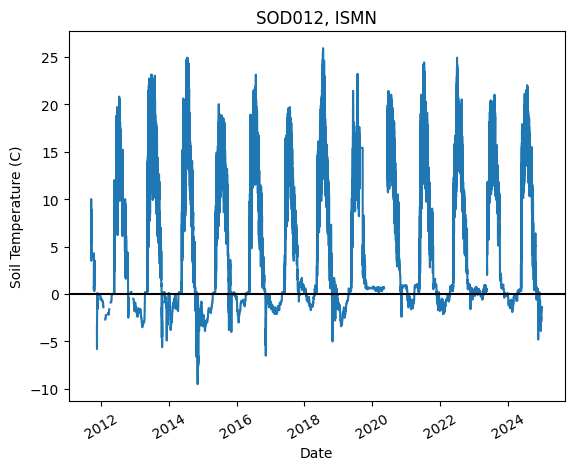

In [31]:
SOD012_df = soil_temp_data_cleaning(data_path=raw_data_path / c.SOD012_NAME,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    temp_threshold=threshold,
                                    date_range=c.DATE_RANGE)

soil_temp_data_reporting(SOD012_df, long_feature=long_variable, station_name=c.SOD012_NAME, ylabel=y_label)

This dataset contains 16 NaN gaps that are longer than 72 hours in duration. Three of these contain at least one F/T transition.
- 2012/10/28 to 2012/11/17 (504 hours)
- 2012/11/25 to 2012/12/15 (504 hours)
- 2011/10/30 to 2011/11/19 (504 hours)

It doesn't seem like there's clear F/T transitions. Zoom in to investigate.

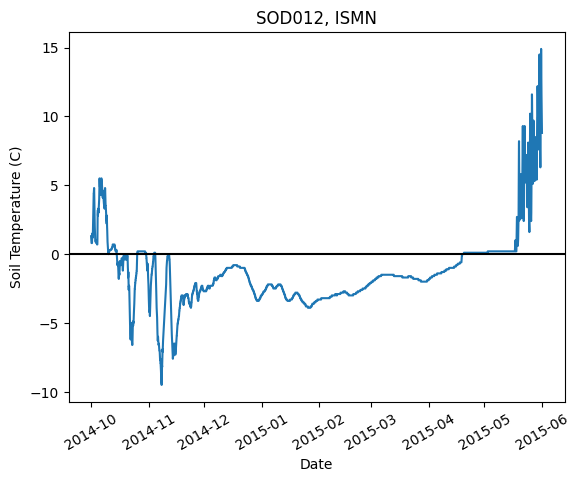

In [32]:
plot(SOD012_df, long_variable, station=c.SOD012_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2014, 10, 1), end=datetime(2015, 6, 1))

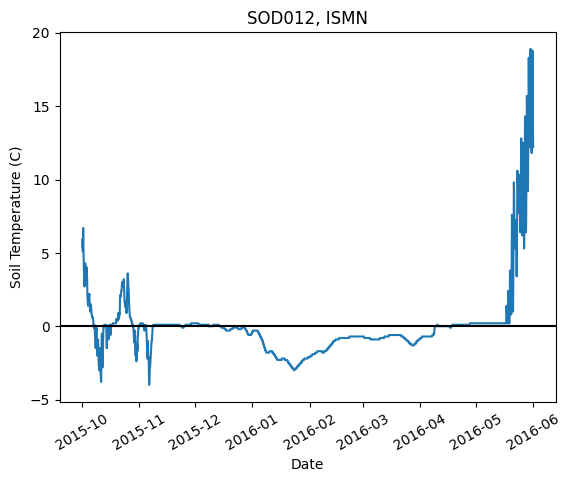

In [33]:
plot(SOD012_df, long_variable, station=c.SOD012_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2015, 10, 1), end=datetime(2016, 6, 1))

Now check the NaN gaps containing possible F/T transitions.

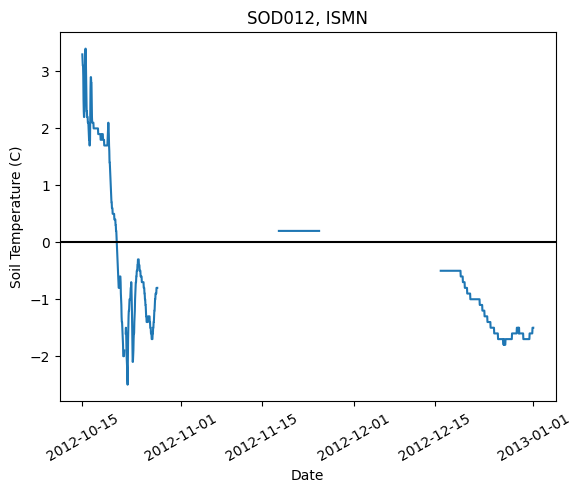

In [34]:
plot(SOD012_df, long_variable, station=c.SOD012_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2012, 10, 15),  end=datetime(2013, 1, 1))

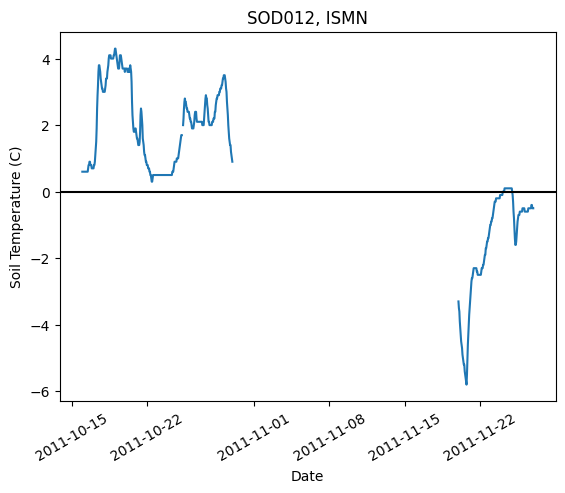

In [35]:
plot(SOD012_df, long_variable, station=c.SOD012_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2011, 10, 15),  end=datetime(2011, 12, 1))

This dataset will likely be problematic in making predictions.

In [36]:
# export to csv
SOD012_df.to_csv(cleaned_data_path / f'{c.SOD012_NAME}_{system}_{short_variable}_{max_depth}.csv')

### 3.10 SOD103

Summary statistics:


,soil_temp
count,103817.000000
mean,4.436372
std,5.186381
min,-3.400000
25%,0.400000
50%,1.300000
75%,9.100000
max,21.000000


Show head of df:


,soil_temp
UTC_timestamp,
2012-10-14 00:00:00+00:00,4.6
2012-10-14 01:00:00+00:00,4.6
2012-10-14 02:00:00+00:00,4.6
2012-10-14 03:00:00+00:00,4.5
2012-10-14 04:00:00+00:00,4.4


There are 3271 nulls out of 107088 datapoints (0.03% missing).
Report NaN gaps greater than 72 hours in duration or contain a possible F/T transition:


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2012-10-28 00:00:00+00:00,2012-11-17 23:00:00+00:00,504,0.8,1.3,False
1,2012-11-25 00:00:00+00:00,2012-12-15 23:00:00+00:00,504,1.4,-0.2,True
8,2019-08-18 00:00:00+00:00,2019-08-24 23:00:00+00:00,168,12.1,9.0,False
9,2020-02-11 11:00:00+00:00,2020-02-15 23:00:00+00:00,109,0.7,0.9,False
10,2020-05-07 11:00:00+00:00,2020-06-13 23:00:00+00:00,901,1.1,10.8,False
11,2020-11-18 11:00:00+00:00,2020-11-21 23:00:00+00:00,85,3.9,1.9,False
13,2023-02-10 11:00:00+00:00,2023-02-18 23:00:00+00:00,205,0.8,0.9,False
15,2023-05-15 11:00:00+00:00,2023-05-20 23:00:00+00:00,133,4.9,6.9,False
17,2024-02-22 11:00:00+00:00,2024-03-09 23:00:00+00:00,397,0.5,1.0,False


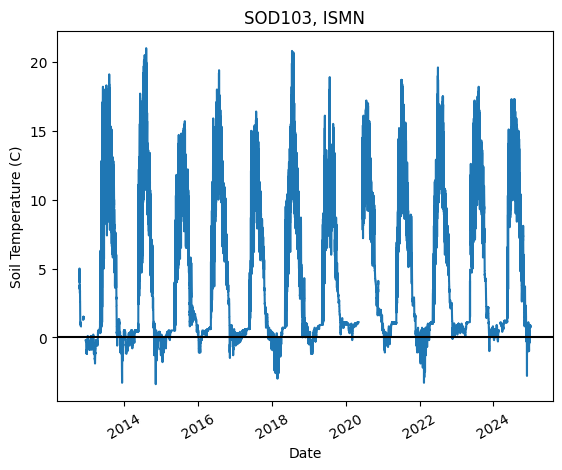

In [37]:
SOD103_df = soil_temp_data_cleaning(data_path=raw_data_path / c.SOD103_NAME,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    temp_threshold=threshold,
                                    date_range=c.DATE_RANGE)

soil_temp_data_reporting(SOD103_df, long_feature=long_variable, station_name=c.SOD103_NAME, ylabel=y_label)

This dataset contains 9 NaN gaps that are longer than 72 hours in duration. Only one gap contains at least one F/T transition:
- 2012/11/25 to 2012/12/15

Plot this time range to investigate.

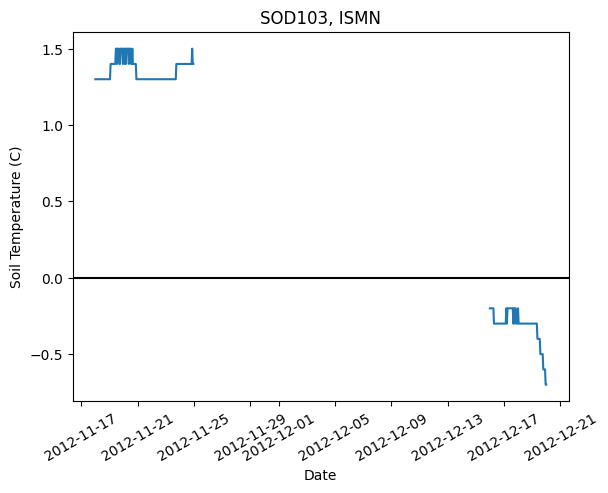

In [38]:
plot(SOD103_df, long_variable, c.SOD103_NAME, system=system, form='line',
     y_label=y_label, start=datetime(2012, 11, 15), end=datetime(2012, 12, 20))

In [39]:
# export to csv
SOD103_df.to_csv(cleaned_data_path / f'{c.SOD103_NAME}_{system}_{short_variable}_{max_depth}.csv')